# 04 — Market Basket Analysis (Association Rules)
**Member D — Association Rules Lead**

Mines frequent itemsets and association rules over invoice-level transactions using **Apriori** and **FP-Growth**, compares their runtimes, and visualises the top-lift rules as a product co-occurrence network.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from src.utils import seed_all, savefig, DATA_PROCESSED, REPORTS_DIR
from src.plot_style import apply_style, PALETTE
from src import association as ar

seed_all(); apply_style()

In [2]:
df = pd.read_parquet(DATA_PROCESSED / 'transactions_clean.parquet')
print(f'Transactions: {len(df):,}  |  Invoices: {df["Invoice"].nunique():,}  |  StockCodes: {df["StockCode"].nunique():,}')
code_to_desc = (df.drop_duplicates('StockCode').set_index('StockCode')['Description'].to_dict())

Transactions: 805,549  |  Invoices: 36,969  |  StockCodes: 4,631


In [3]:
# To keep mining tractable, restrict to items present in >= 0.5% of invoices.
min_inv_frac = 0.005
min_inv = max(50, int(min_inv_frac * df['Invoice'].nunique()))
code_counts = df.groupby('StockCode')['Invoice'].nunique()
popular_codes = set(code_counts[code_counts >= min_inv].index)
print(f'Keeping {len(popular_codes):,} popular StockCodes (>= {min_inv} invoices)')

df_pop = df[df['StockCode'].isin(popular_codes)]
txs = ar.build_transactions(df_pop, item_col='StockCode')
print(f'Resulting transactions: {len(txs):,}  |  avg basket: {np.mean([len(t) for t in txs]):.1f} items')
encoded = ar.encode_transactions(txs)
encoded.shape

Keeping 1,188 popular StockCodes (>= 184 invoices)


Resulting transactions: 35,922  |  avg basket: 16.3 items


(35922, 1188)

## 1. Apriori vs FP-Growth — same params, compare runtime

In [4]:
params = dict(min_support=0.02, min_confidence=0.5, min_lift=1.5)

freq_ap, rules_ap, rt_ap = ar.mine_rules(encoded, 'apriori', **params)
freq_fp, rules_fp, rt_fp = ar.mine_rules(encoded, 'fpgrowth', **params)

runtime_table = pd.DataFrame({
    'Algorithm':      ['Apriori', 'FP-Growth'],
    'Freq itemsets':  [len(freq_ap), len(freq_fp)],
    'Rules (lift>=1.5)':[len(rules_ap), len(rules_fp)],
    'Runtime (s)':    [round(rt_ap, 3), round(rt_fp, 3)],
})
runtime_table.to_csv(REPORTS_DIR / 'apriori_vs_fpgrowth.csv', index=False)
runtime_table

,Algorithm,Freq itemsets,Rules (lift>=1.5),Runtime (s)
0,Apriori,242,17,6.084
1,FP-Growth,242,17,4.150


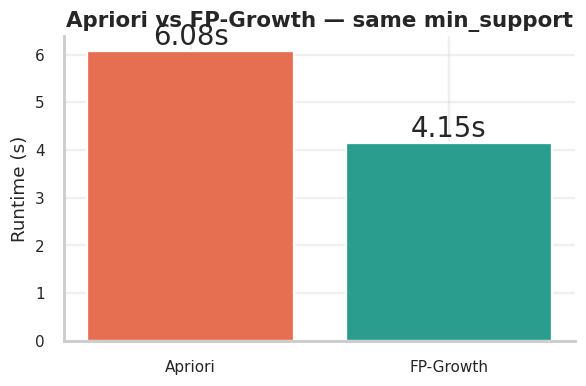

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.bar(runtime_table['Algorithm'], runtime_table['Runtime (s)'],
       color=[PALETTE[4], PALETTE[1]])
ax.set_ylabel('Runtime (s)')
ax.set_title('Apriori vs FP-Growth — same min_support')
for i, v in enumerate(runtime_table['Runtime (s)']):
    ax.text(i, v, f'{v:.2f}s', ha='center', va='bottom')
savefig(fig, '04_apriori_vs_fpgrowth'); plt.show()

## 2. Top-30 rules by lift (with product descriptions)

In [6]:
rules = ar.prune_redundant(rules_fp).sort_values('lift', ascending=False).head(30)
rules = ar.add_descriptions(rules, code_to_desc)
out_cols = ['antecedents_desc','consequents_desc','support','confidence','lift']
rules[out_cols].to_csv(REPORTS_DIR / 'association_rules.csv', index=False)
rules[out_cols].head(15)

,antecedents_desc,consequents_desc,support,confidence,lift
0,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.020990,0.704673,26.758203
1,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.020990,0.797040,26.758203
2,SWEETHEART CERAMIC TRINKET BOX,STRAWBERRY CERAMIC TRINKET BOX,0.023857,0.731853,13.887812
3,WOODEN PICTURE FRAME WHITE FINISH,WOODEN FRAME ANTIQUE WHITE,0.027643,0.598914,12.134349
4,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,0.027643,0.560068,12.134349
5,LOVE BUILDING BLOCK WORD,HOME BUILDING BLOCK WORD,0.021881,0.529293,10.384086
6,LUNCHBAG PINK RETROSPOT,LUNCH BAG RED SPOTTY,0.028451,0.553930,7.715493
7,PACK OF 60 PINK PAISLEY CAKE CASES,PACK OF 72 RETRO SPOT CAKE CASES,0.023662,0.538657,7.715159
8,JUMBO BAG STRAWBERRY,JUMBO BAG RED WHITE SPOTTY,0.026502,0.628798,6.928735
9,RED HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,0.032153,0.708155,5.196798


## 3. Top-20 rule network visualisation

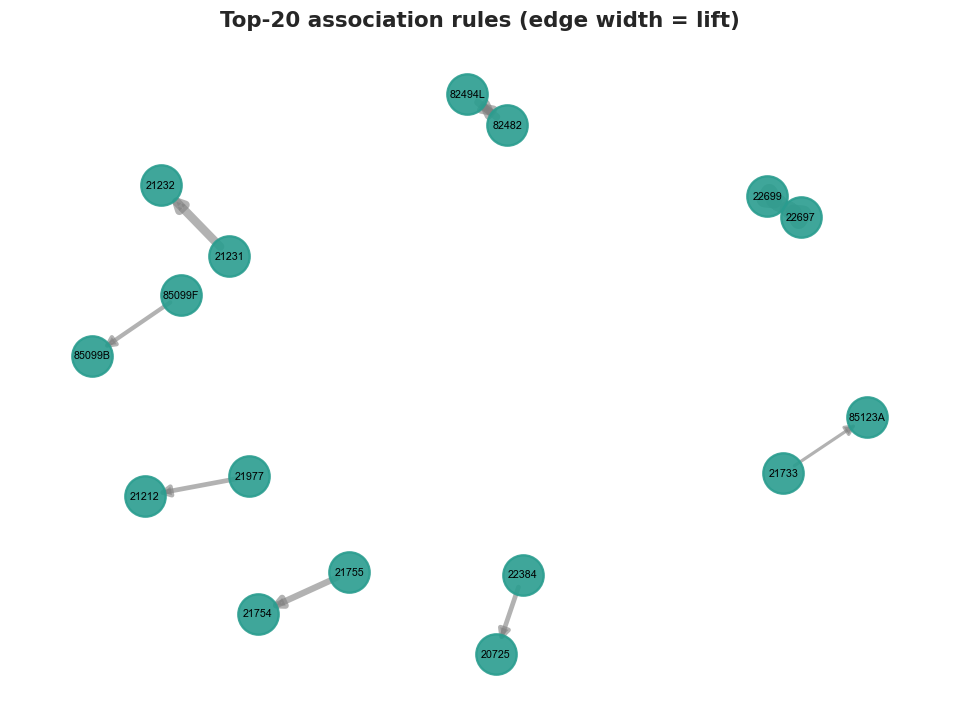

In [7]:
G = nx.DiGraph()
for _, r in rules.head(20).iterrows():
    a = ', '.join(sorted(r['antecedents']))[:25]
    c = ', '.join(sorted(r['consequents']))[:25]
    G.add_edge(a, c, weight=float(r['lift']))

fig, ax = plt.subplots(figsize=(11, 8))
pos = nx.spring_layout(G, seed=42, k=0.9)
weights = [G[u][v]['weight'] for u,v in G.edges()]
nx.draw_networkx_nodes(G, pos, node_size=700, node_color=PALETTE[1], alpha=0.9, ax=ax)
nx.draw_networkx_edges(G, pos, width=[w*0.4 for w in weights], alpha=0.6,
                       edge_color='gray', arrows=True, arrowsize=14, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
ax.set_title('Top-20 association rules (edge width = lift)')
ax.set_axis_off()
savefig(fig, '04_rule_network'); plt.show()

## 4. Support / confidence / lift scatter — full rule space

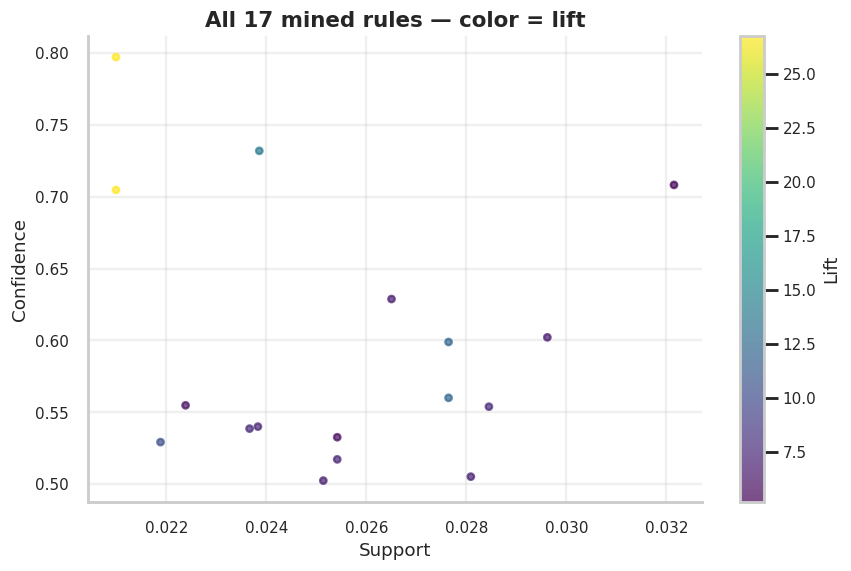

In [8]:
fig, ax = plt.subplots()
sc = ax.scatter(rules_fp['support'], rules_fp['confidence'], c=rules_fp['lift'],
                cmap='viridis', alpha=0.7, s=18)
ax.set_xlabel('Support'); ax.set_ylabel('Confidence')
ax.set_title(f'All {len(rules_fp)} mined rules — color = lift')
plt.colorbar(sc, label='Lift')
savefig(fig, '04_rule_scatter'); plt.show()